# Инференс: TabTransformer (MLflow PyTorch)

Загрузка модели из MLflow и предсказание на тестовой выборке.

In [37]:
all_results = {}

In [69]:
pip install transtab


  Using cached transtab-0.0.5-py3-none-any.whl.metadata (5.4 kB)
  Using cached openml-0.15.1-py3-none-any.whl.metadata (10 kB)
  Using cached liac_arff-2.5.0-py3-none-any.whl
  Using cached xmltodict-1.0.4-py3-none-any.whl.metadata (14 kB)
  Using cached minio-7.2.20-py3-none-any.whl.metadata (6.5 kB)
  Using cached pycryptodome-3.23.0-cp37-abi3-win_amd64.whl.metadata (3.5 kB)
Using cached transtab-0.0.5-py3-none-any.whl (29 kB)
Using cached openml-0.15.1-py3-none-any.whl (160 kB)
Using cached minio-7.2.20-py3-none-any.whl (93 kB)
Using cached xmltodict-1.0.4-py3-none-any.whl (13 kB)
Using cached pycryptodome-3.23.0-cp37-abi3-win_amd64.whl (1.8 MB)


In [63]:
import pandas as pd
import numpy as np
import torch
import sys
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
PROJECT_ROOT = r'C:\Users\Danch\PycharmProjects\Credit_Scoring_Model_w_transformers'

# ← ВАЖНО: до импорта mlflow
sys.path.insert(0, PROJECT_ROOT)

import mlflow
import mlflow.pytorch

MODEL_PATH        = PROJECT_ROOT + r'\mlartifacts\0\models\m-455a548c843e462f86c6683202081488'
PREPROCESSOR_PATH = r'C:\Users\Danch\PycharmProjects\Credit_Scoring_Model_w_transformers\mlartifacts\0\981c5fa53f014a00bafbf69702383704\artifacts\preprocessors\preprocessors.pkl'
TEST_PATH         = r'C:\Users\Danch\Downloads\files\test_final.csv'
VAL_PATH          = r'C:\Users\Danch\Downloads\files\validate_final.csv'
OUTPUT_PATH       = r'C:\Users\Danch\Downloads\files\predictions_new.csv'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cpu


In [64]:
# pip install python-multipart
# pip install sentence-transformers

## 1. Загрузка модели

In [65]:
# MODE_PATH = r'C:\Users\Danch\PycharmProjects\Credit_Scoring_Model_w_transformers\mlartifacts\0\models\m-60c080047dc14b4586f22144677c5c3d\artifacts\data\model.pth'

# model = mlflow.pytorch.load_model(MODEL_PATH, map_location=DEVICE)
# model.eval()
# model.to(DEVICE)
# print('Загружена!')
# print(f'Параметров: {sum(p.numel() for p in model.parameters()):,}')

# MODEL_PATH = r"C:\Users\Danch\PycharmProjects\Credit_Scoring_Model_w_transformers\mlartifacts\0\models\m-0e0b8bf59bf54751a46b4e6a4c8ad7ee\artifacts\data\model.pth"

import pickle
import os 
# Ищем все файлы в папке рекурсивно
print("Ищем файлы модели...")
model_file = None
for root, dirs, files in os.walk(MODEL_PATH):
    for f in files:
        if f.endswith('.pth') or f.endswith('.pkl') or f.endswith('.pt'):
            model_file = os.path.join(root, f)
            print(f"  Найден: {f} ({os.path.getsize(model_file)} bytes)")

if model_file is None:
    print("❌ Файл модели не найден!")
else:
    print(f"\nЗагружаем: {model_file}")
    
    # Пробуем pickle
    if model_file.endswith('.pkl'):
        print("→ Расширение .pkl, загружаем через pickle...")
        with open(model_file, 'rb') as f:
            model = pickle.load(f)
        print(f'✅ Загружен через pickle! Тип: {type(model)}')

        if model_file.endswith('.pkl') or header == b'\x80\x04':
            # Pickle pipeline — clf готов сразу
            clf = model
            print(f'✅ clf = pickle pipeline: {type(clf)}')
    # Пробуем torch
    elif model_file.endswith('.pth') or model_file.endswith('.pt'):
        # Проверяем, не pickle ли это на самом деле
        with open(model_file, 'rb') as f:
            header = f.read(2)
        
        if header == b'\x80\x04':  # Pickle header
            print("→ Это pickle-файл с расширением .pth, загружаем через pickle...")
            with open(model_file, 'rb') as f:
                model = pickle.load(f)
            print(f'✅ Загружен через pickle! Тип: {type(model)}')
        else:
            print("→ Загружаем через torch.load...")
            model = torch.load(model_file, map_location=DEVICE, weights_only=False)
            model.eval()
            model.to(DEVICE)
            print(f'✅ Загружен через torch! Параметров: {sum(p.numel() for p in model.parameters()):,}')

Ищем файлы модели...
  Найден: model.pth (1086018 bytes)

Загружаем: C:\Users\Danch\PycharmProjects\Credit_Scoring_Model_w_transformers\mlartifacts\0\models\m-455a548c843e462f86c6683202081488\artifacts\data\model.pth
→ Загружаем через torch.load...
✅ Загружен через torch! Параметров: 257,030


## 2. Загрузка препроцессора

In [66]:
sys.path.append(PROJECT_ROOT)
from backend.transformers_.tabtransformer_direct import DirectTabTransformer

clf = DirectTabTransformer()
clf.load_preprocessors(PREPROCESSOR_PATH)
clf.model_  = model
clf.device_ = DEVICE

print(f'Числовых фич:       {len(clf.num_features_)}')
print(f'Категориальных фич: {len(clf.cat_features_)}')

Числовых фич:       34
Категориальных фич: 4


## 3. Подбор порога на валидации

In [8]:
# from sklearn.metrics import roc_auc_score, roc_curve, f1_score, confusion_matrix
# import matplotlib.pyplot as plt

# val = pd.read_csv(r'C:\Users\Danch\Downloads\files\validate_final.csv')
# y_val = val['default_flg'].values
# X_val = val.drop(columns=['id', 'default_flg'])

# # X_val['app_quarter'] = (X_val['app_month'] - 1) // 3 + 1

# # И аналогично для теста перед predict_proba(test)
# # test['app_quarter'] = (test['app_month'] - 1) // 3 + 1

# val_probas = clf.predict_proba(X_val)[:, 1]
# val_auc    = roc_auc_score(y_val, val_probas)
# print(f'Validation AUC: {val_auc:.4f}')

# fpr, tpr, thresholds = roc_curve(y_val, val_probas)
# f1_scores = [f1_score(y_val, (val_probas >= t).astype(int)) for t in thresholds]
# best_idx  = int(np.argmax(f1_scores))
# THRESHOLD = float(thresholds[best_idx])
# print(f'Оптимальный порог (F1): {THRESHOLD:.4f}')
# print(f'Лучший F1:              {f1_scores[best_idx]:.4f}')

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# axes[0].plot(fpr, tpr, lw=2, label=f'AUC={val_auc:.4f}')
# axes[0].plot([0,1],[0,1],'k--', lw=1)
# axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
# axes[0].set_title('ROC Curve (Validation)'); axes[0].legend()
# axes[1].plot(thresholds, f1_scores, color='#e74c3c', lw=2)
# axes[1].axvline(THRESHOLD, color='black', linestyle='--', label=f'Порог={THRESHOLD:.3f}')
# axes[1].set_xlabel('Порог'); axes[1].set_ylabel('F1')
# axes[1].set_title('F1 vs Порог'); axes[1].legend()
# plt.tight_layout(); plt.show()

# val_pred = (val_probas >= THRESHOLD).astype(int)
# tn, fp, fn, tp = confusion_matrix(y_val, val_pred).ravel()
# print(f'TN={tn:,}  FP={fp:,}')
# print(f'FN={fn:,}  TP={tp:,}')
# print(f'Precision: {tp/(tp+fp):.4f}  Recall: {tp/(tp+fn):.4f}')

## 4. Предсказание на тесте

Cat categories in tabtransformer:  ['education_cd', 'gender_cd', 'car_own_flg', 'car_type_flg', 'Air_flg']
[predict_proba] 24480 rows, 192 batch...
[predict_proba] 38/192 batch | 15899 rows/sec | ETA: 1.2s
[predict_proba] 76/192 batch | 16445 rows/sec | ETA: 0.9s
[predict_proba] 114/192 batch | 16210 rows/sec | ETA: 0.6s
[predict_proba] 152/192 batch | 16284 rows/sec | ETA: 0.3s
[predict_proba] 190/192 batch | 16399 rows/sec | ETA: 0.0s
Строк: 24480
min=0.0364  max=0.8845  mean=0.3028


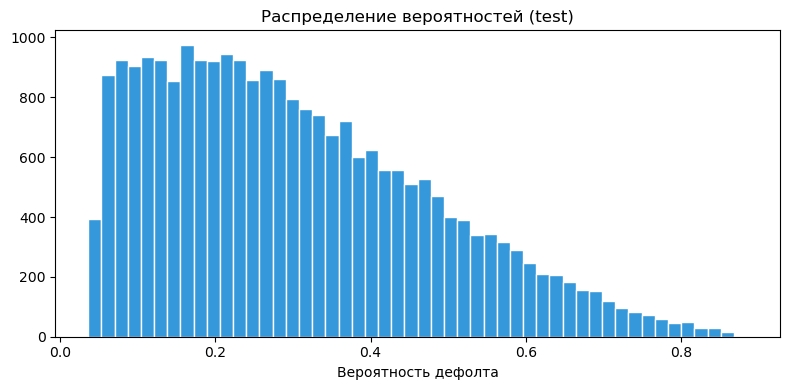

In [11]:
# test     = pd.read_csv(TEST_PATH)
# test_ids = test['id'].values
# X_test   = test.drop(columns=['id'])

# prob_default = clf.predict_proba(X_test)[:, 1]

# print(f'Строк: {len(prob_default)}')
# print(f'min={prob_default.min():.4f}  max={prob_default.max():.4f}  mean={prob_default.mean():.4f}')

# plt.figure(figsize=(8, 4))
# plt.hist(prob_default, bins=50, color='#3498db', edgecolor='white')
# plt.xlabel('Вероятность дефолта')
# plt.title('Распределение вероятностей (test)')
# plt.tight_layout()
# plt.show()

## 5. Сохранение

In [12]:
result = pd.DataFrame({
    'id':    test_ids,
    'score': prob_default
})
result.to_csv(OUTPUT_PATH, index=False)
print(f'Сохранено: {OUTPUT_PATH}')
result.head(10)

Сохранено: C:\Users\Danch\Downloads\files\predictions_new.csv


,id,score
0,180817,0.366368
1,180818,0.446056
2,180819,0.359428
3,180820,0.511332
4,180821,0.239298
5,180822,0.535727
6,180823,0.303725
7,180824,0.078651
8,180825,0.371497
9,180826,0.317974


Cat categories in tabtransformer:  ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
[predict_proba] 20000 rows, 157 batch...
[predict_proba] 31/157 batch | 6086 rows/sec | ETA: 2.6s
[predict_proba] 62/157 batch | 6797 rows/sec | ETA: 1.8s
[predict_proba] 93/157 batch | 6984 rows/sec | ETA: 1.2s
[predict_proba] 124/157 batch | 7142 rows/sec | ETA: 0.6s
[predict_proba] 155/157 batch | 7268 rows/sec | ETA: 0.0s
[FeatureSemanticMatcher]
  Строк:    20000
  Время:    2.765s
  rows/sec: 7234
  ms/row:   0.1382
  ROC-AUC:  0.8916
  min=0.0003  max=0.9543  mean=0.3729


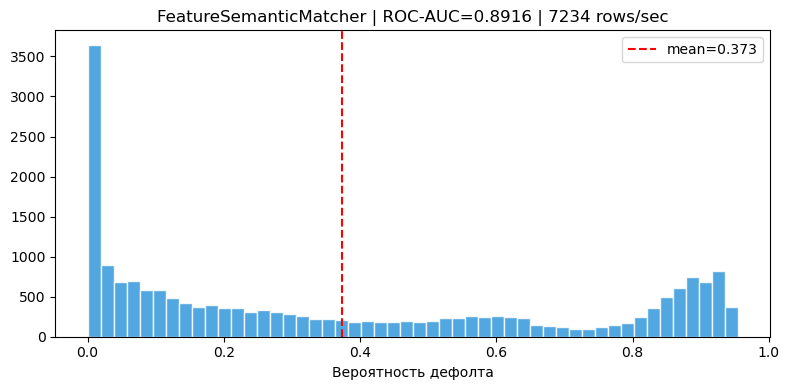

In [67]:
# ── Загрузка тестовой выборки ────────────────────────────────

import time
from sklearn.metrics import roc_auc_score, roc_curve
TEST_PATH = r'C:\Users\Danch\PycharmProjects\Credit_Scoring_Model_w_transformers\data\Dataset_C\credit_scoring_test.csv'

test     = pd.read_csv(TEST_PATH)
test_ids = test['Customer_ID'].values
y_true   = test['target'].values
X_test   = test.drop(columns=['Customer_ID', 'target'])

# ── Инференс с замером времени ───────────────────────────────
MODEL_NAME = 'FeatureSemanticMatcher'  # ← меняй для каждой модели

start = time.time()
prob_default = clf.predict_proba(X_test)[:, 1]
elapsed = time.time() - start

rows_per_sec = len(X_test) / elapsed
latency_ms   = elapsed / len(X_test) * 1000
auc          = roc_auc_score(y_true, prob_default)
fpr, tpr, _  = roc_curve(y_true, prob_default)

print(f'[{MODEL_NAME}]')
print(f'  Строк:    {len(prob_default)}')
print(f'  Время:    {elapsed:.3f}s')
print(f'  rows/sec: {rows_per_sec:.0f}')
print(f'  ms/row:   {latency_ms:.4f}')
print(f'  ROC-AUC:  {auc:.4f}')
print(f'  min={prob_default.min():.4f}  max={prob_default.max():.4f}  mean={prob_default.mean():.4f}')

# ── Сохраняем результаты ─────────────────────────────────────
# Инициализируй один раз перед первой моделью:
# all_results = {}

all_results[MODEL_NAME] = {
    'probs':       prob_default,
    'fpr':         fpr,
    'tpr':         tpr,
    'auc':         auc,
    'rows_per_sec': rows_per_sec,
    'latency_ms':  latency_ms,
    'elapsed':     elapsed,
}

# ── График распределения ─────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.hist(prob_default, bins=50, color='#3498db', edgecolor='white', alpha=0.85)
plt.axvline(prob_default.mean(), color='red', linestyle='--',
            label=f'mean={prob_default.mean():.3f}')
plt.xlabel('Вероятность дефолта')
plt.title(f'{MODEL_NAME} | ROC-AUC={auc:.4f} | {rows_per_sec:.0f} rows/sec')
plt.legend()
plt.tight_layout()
plt.show()

In [78]:
import transtab
import json
# ── Загрузка TransTab ────────────────────────────────────────
MODEL_DIR_TT = r'C:\Users\Danch\PycharmProjects\Credit_Scoring_Model_w_transformers\backend\transformers_transtab_checkpoints'
# В папке должны быть: pytorch_model.bin, extractor.json, tokenizer_config.json
MODEL_NAME = 'TransTab' 
with open(r'C:\Users\Danch\PycharmProjects\Credit_Scoring_Model_w_transformers\backend\transformers_\transtab_checkpoints\extractor\extractor.json') as f:
    extractor = json.load(f)

cat_cols    = extractor.get('categorical', None)
num_cols    = extractor.get('numerical', None)
binary_cols = extractor.get('binary', None)

# ── Загрузка с явными колонками и CPU ───────────────────────
model = transtab.build_classifier(
    categorical_columns = cat_cols,
    numerical_columns   = num_cols,
    binary_columns      = binary_cols,
    checkpoint          = r'C:\Users\Danch\PycharmProjects\Credit_Scoring_Model_w_transformers\backend\transformers_\transtab_checkpoints',
    device              = 'cpu',  # ← принудительно CPU
)
model.eval()

# ── Инференс ─────────────────────────────────────────────────
y_test_series = pd.Series(y_true, name='target')

n = len(X_test)
start = time.time()

prob_transtab = transtab.predict(
    model, 
    X_test, 
    y_test=y_test_series  # ← передай y_test
)
elapsed = time.time() - start

# Проверяем форму вывода
print(f'prob shape: {prob_transtab.shape}')
print(f'prob[:5]: {prob_transtab[:5]}')

# Если shape=[N, 2] берём второй столбец:
if prob_transtab.ndim == 2:
    prob_transtab = prob_transtab[:, 1]

auc         = roc_auc_score(y_true, prob_transtab)
fpr, tpr, _ = roc_curve(y_true, prob_transtab)

print(f'\n[TransTab]')
print(f'  ROC-AUC:  {auc:.4f}')
print(f'  rows/sec: {n/elapsed:.0f}')
print(f'  ms/row:   {elapsed/n*1000:.4f}')

all_results['TransTab'] = {
    'model':        'TransTab',
    'probs':        prob_transtab,
    'fpr':          fpr,
    'tpr':          tpr,
    'auc':          round(auc, 4),
    'rows_per_sec': int(n/elapsed),
    'latency_ms':   round(elapsed/n*1000, 4),
    'elapsed':      round(elapsed, 3),
}

2026-05-18 17:03:42.091 | INFO     | transtab.modeling_transtab:load:774 - missing keys: []
2026-05-18 17:03:42.091 | INFO     | transtab.modeling_transtab:load:775 - unexpected keys: []
2026-05-18 17:03:42.092 | INFO     | transtab.modeling_transtab:load:776 - load model from C:\Users\Danch\PycharmProjects\Credit_Scoring_Model_w_transformers\backend\transformers_\transtab_checkpoints
2026-05-18 17:03:42.136 | INFO     | transtab.modeling_transtab:load:222 - load feature extractor from C:\Users\Danch\PycharmProjects\Credit_Scoring_Model_w_transformers\backend\transformers_\transtab_checkpoints\extractor\extractor.json


prob shape: (20000,)
prob[:5]: [0.71321535 0.14217879 0.092257   0.14912038 0.5766367 ]

[TransTab]
  ROC-AUC:  0.8221
  rows/sec: 1307
  ms/row:   0.7649


In [82]:
all_results["TransTab"]

{'model': 'TransTab',
 'probs': array([0.71321535, 0.14217879, 0.092257  , ..., 0.07435761, 0.12004095,
        0.08446644], dtype=float32),
 'fpr': array([0.00000000e+00, 7.04225352e-05, 7.04225352e-05, ...,
        9.97746479e-01, 9.97746479e-01, 1.00000000e+00]),
 'tpr': array([0.        , 0.        , 0.0012069 , ..., 0.99982759, 1.        ,
        1.        ]),
 'auc': 0.8221,
 'rows_per_sec': 1307,
 'latency_ms': 0.7649,
 'elapsed': 15.298}

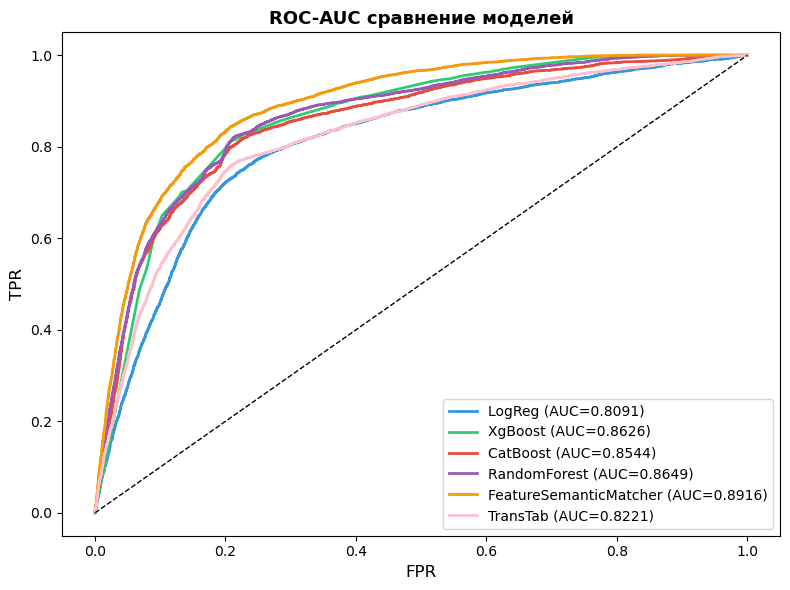


Модель                    AUC   rows/sec     ms/row
----------------------------------------------------
LogReg                 0.8091     405660     0.0025
XgBoost                0.8626     174872     0.0057
CatBoost               0.8544      52036     0.0192
RandomForest           0.8649     260263     0.0038
FeatureSemanticMatcher   0.8916       7234     0.1382
TransTab               0.8221       1307     0.7649


In [84]:
# ── Общий ROC-AUC график ─────────────────────────────────────
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', 'pink']

plt.figure(figsize=(8, 6))
for (name, res), color in zip(all_results.items(), colors):
    plt.plot(res['fpr'], res['tpr'], color=color, lw=2,
             label=f'{name} (AUC={res["auc"]:.4f})')

plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('FPR', fontsize=12)
plt.ylabel('TPR', fontsize=12)
plt.title('ROC-AUC сравнение моделей', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150)
plt.show()

# ── Таблица инференса ────────────────────────────────────────
print(f'\n{"Модель":<20} {"AUC":>8} {"rows/sec":>10} {"ms/row":>10}')
print('-' * 52)
for name, res in all_results.items():
    print(f'{name:<20} {res["auc"]:>8.4f} {res["rows_per_sec"]:>10.0f} {res["latency_ms"]:>10.4f}')

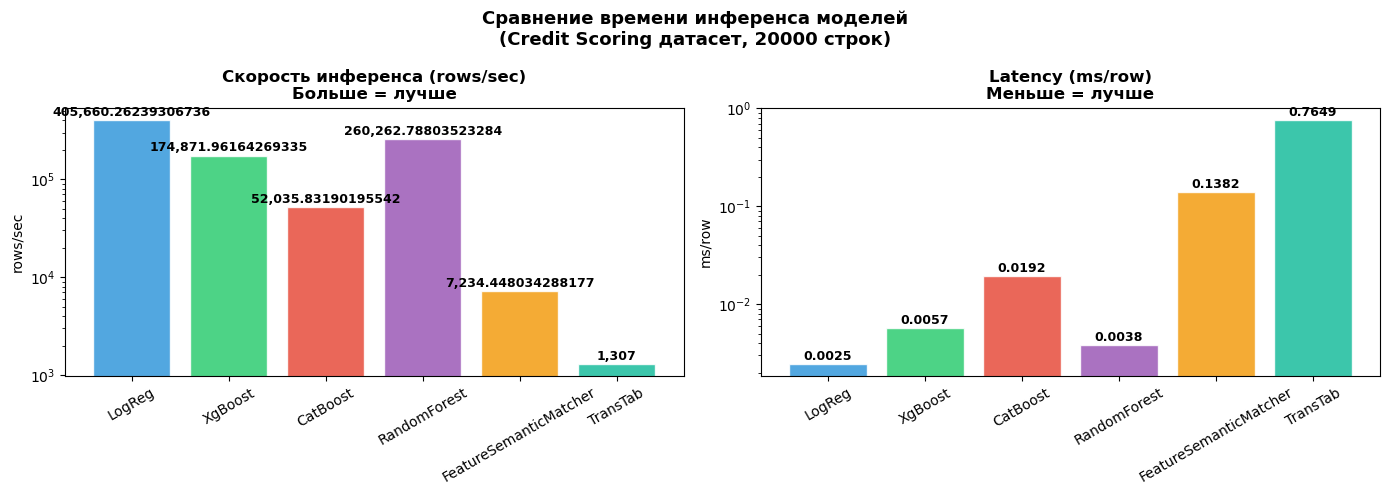

Сохранено: inference_speed.png


In [85]:
# ── График времени инференса ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names     = list(all_results.keys())
rps       = [all_results[n]['rows_per_sec'] for n in names]
latency   = [all_results[n]['latency_ms']   for n in names]
colors    = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c']

# График 1 — rows/sec (больше = лучше)
bars = axes[0].bar(names, rps, color=colors, edgecolor='white', alpha=0.85)
axes[0].set_title('Скорость инференса (rows/sec)\nБольше = лучше', fontsize=12, fontweight='bold')
axes[0].set_ylabel('rows/sec')
axes[0].set_yscale('log')  # лог шкала из-за большого разброса
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, rps):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')

# График 2 — latency ms/row (меньше = лучше)
bars2 = axes[1].bar(names, latency, color=colors, edgecolor='white', alpha=0.85)
axes[1].set_title('Latency (ms/row)\nМеньше = лучше', fontsize=12, fontweight='bold')
axes[1].set_ylabel('ms/row')
axes[1].set_yscale('log')
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars2, latency):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Сравнение времени инференса моделей\n(Credit Scoring датасет, 20000 строк)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('inference_speed.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: inference_speed.png')